In [38]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [39]:
X, y = make_classification(
    n_samples=500,
    n_features=5,
    n_informative=3,
    n_classes=2,
    random_state=42
)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [40]:
depths = [1, 3, 5, 10, None]

for d in depths:
    model = DecisionTreeClassifier(max_depth=d, random_state=42)
    model.fit(X_train, y_train)

    train_acc = model.score(X_train, y_train)
    test_acc = model.score(X_test, y_test)

    print(f"Depth: {d}, Train Acc: {train_acc:.2f}, Test Acc: {test_acc:.2f}")

Depth: 1, Train Acc: 0.88, Test Acc: 0.85
Depth: 3, Train Acc: 0.95, Test Acc: 0.94
Depth: 5, Train Acc: 0.97, Test Acc: 0.93
Depth: 10, Train Acc: 1.00, Test Acc: 0.93
Depth: None, Train Acc: 1.00, Test Acc: 0.93


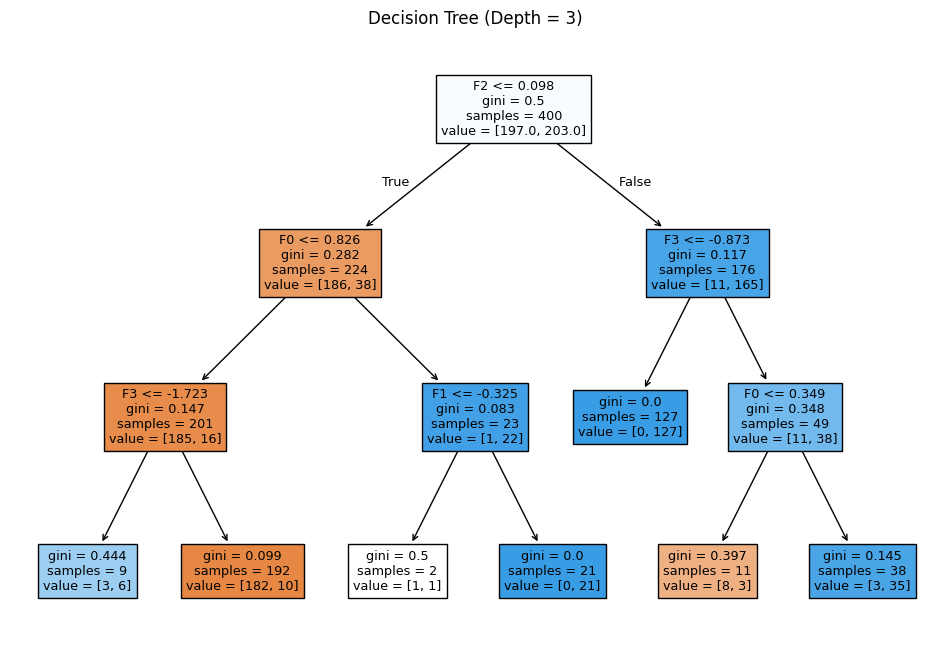

In [41]:
from sklearn.tree import plot_tree

model = DecisionTreeClassifier(max_depth=3, random_state=42)
model.fit(X_train, y_train)

plt.figure(figsize=(12, 8))
plot_tree(model, filled=True, feature_names=[f"F{i}" for i in range(X.shape[1])])
plt.title("Decision Tree (Depth = 3)")
plt.show()

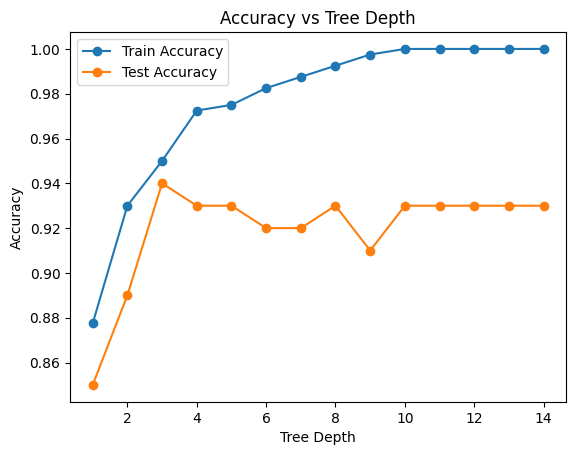

Best depth: 3


In [42]:
train_accs = []
test_accs = []
depth_range = range(1, 15)

for d in depth_range:
    model = DecisionTreeClassifier(max_depth=d, random_state=42)
    model.fit(X_train, y_train)

    train_accs.append(model.score(X_train, y_train))
    test_accs.append(model.score(X_test, y_test))

# Plot
plt.plot(depth_range, train_accs, marker='o', label='Train Accuracy')
plt.plot(depth_range, test_accs, marker='o', label='Test Accuracy')

plt.xlabel("Tree Depth")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Tree Depth")
plt.legend()
plt.show()
best_depth = depth_range[test_accs.index(max(test_accs))]
print("Best depth:", best_depth)

In [43]:
X_2d = X[:, :2]

X_train_2d, X_test_2d, y_train, y_test = train_test_split(
    X_2d, y, test_size=0.2, random_state=42
)

In [44]:
model = DecisionTreeClassifier(max_depth=3, random_state=42)
model.fit(X_train_2d, y_train)

DecisionTreeClassifier(max_depth=3, random_state=42)

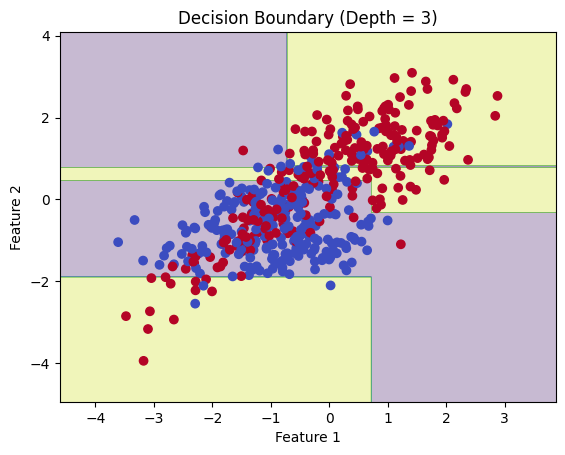

In [45]:
# Create grid
x_min, x_max = X_2d[:, 0].min() - 1, X_2d[:, 0].max() + 1
y_min, y_max = X_2d[:, 1].min() - 1, X_2d[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.02),
    np.arange(y_min, y_max, 0.02)
)

# Predict over grid
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y, cmap='coolwarm')
plt.title("Decision Boundary (Depth = 3)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

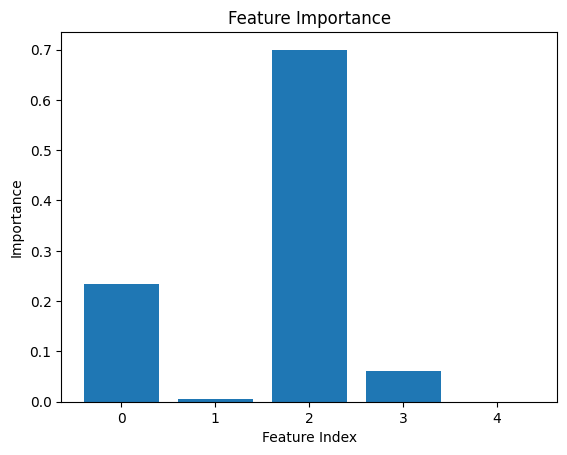

In [46]:
import pandas as pd
model = DecisionTreeClassifier(max_depth=3, random_state=42)
model.fit(X_train, y_train)
importance = model.feature_importances_
plt.bar(range(len(importance)), importance)
plt.xlabel("Feature Index")
plt.ylabel("Importance")
plt.title("Feature Importance")
plt.show()

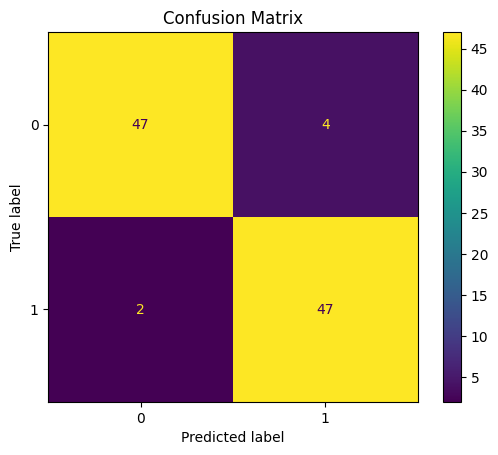

In [47]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

model = DecisionTreeClassifier(max_depth=3, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

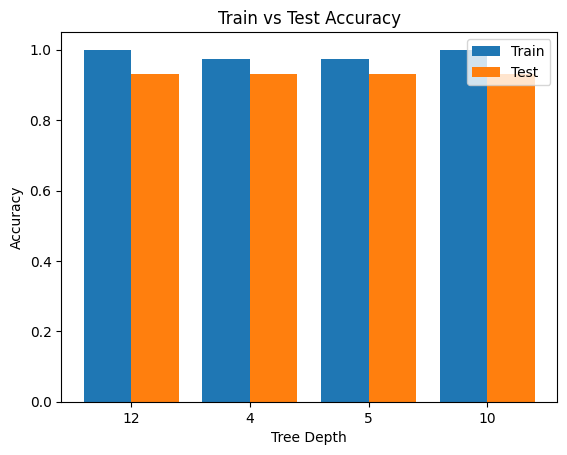

In [48]:
depths = [12, 4, 5, 10]

train_scores = []
test_scores = []

for d in depths:
    model = DecisionTreeClassifier(max_depth=d, random_state=42)
    model.fit(X_train, y_train)

    train_scores.append(model.score(X_train, y_train))
    test_scores.append(model.score(X_test, y_test))

x = np.arange(len(depths))

plt.bar(x - 0.2, train_scores, width=0.4, label='Train')
plt.bar(x + 0.2, test_scores, width=0.4, label='Test')

plt.xticks(x, depths)
plt.xlabel("Tree Depth")
plt.ylabel("Accuracy")
plt.title("Train vs Test Accuracy")
plt.legend()
plt.show()